# Lab 7 — SIS, LWE, and the noise that makes it real

**Maths for Post-Quantum Cryptography**, Chapter 7: *SIS and LWE*

---

Four pieces. Part A solves the running SIS instance by brute force,
confirming Derivation 7.1's guaranteed radius. Part B builds a toy
decision-LWE oracle and runs Derivation 7.2's search-to-decision reduction
against it as a genuine black box, never touching the secret directly.
Part C samples the centered binomial distribution CBD_eta and a discrete
Gaussian side by side, confirms Derivation 7.3's variance formula, and
looks honestly at the control-flow difference the chapter's constant-time
note describes. Part D reproduces both panels of Figure 7.1 numerically —
one correct decode, one genuine decoding failure.

**Part A — SIS by brute force.** Reuse Chapter 6's exhaustive search
machinery on $\Lambda_q^\perp(A)$; reproduce the $q=5$, $A=(2,1)$ example.

**Part B — the search-to-decision reduction, for real.** A toy oracle,
used only as a black box, recovers the secret one coordinate at a time.

**Part C — $\mathrm{CBD}_\eta$ against a discrete Gaussian.** Variance
check, plus an honest look at rejection-sampling's data-dependent
iteration count.

**Part D — Figure 7.1, both ways.** One target decodes correctly, the
other decodes to the wrong secret.

### Requirements

```
python >= 3.9
numpy
matplotlib
```

Nothing else — every algorithm here is written directly from the chapter's
definitions, in plain Python, with no lattice-reduction library and no use
of a real cryptographic library's sampler (that would defeat the point of
Part C entirely).

### How to use this notebook

Run it top to bottom once. Worked solutions for the pencil-and-paper
exercises (7.1-7.8) are in Appendix C of the book.

Every section ends with `assert` statements, and the final cell is a single
`_selftest()` that repeats all of them. CI runs this notebook on every
commit; if an assertion fires on your machine, that is a bug in the lab, not
in your understanding — please open an issue.

In [1]:
from __future__ import annotations

import itertools
import random
import time
from math import sqrt

import numpy as np
import matplotlib.pyplot as plt

# Same print-safe, black-and-white styling as Labs 1-6.
plt.rcParams.update({
    "figure.figsize": (7.5, 3.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.prop_cycle": plt.cycler(color=["0.15", "0.45", "0.65"]),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

random.seed(0)
np.random.seed(0)
print(f"numpy {np.__version__}")

numpy 2.4.4


---

## Part A — SIS by brute force

$\mathrm{SIS}_{q,m,n,\beta}$ asks for a short nonzero $x$ with $Ax\equiv0
\pmod q$ — exactly SVP on $\Lambda_q^\perp(A)$ (Definition 6.1 restricted to
this lattice family), so the same exhaustive-search idea Lab 6 used for SVP
solves it directly. Reproduces the running example: $q=5$, $A=(2,1)$, and
the shortest nonzero solutions are $(2,1)$, $(-1,2)$ and their negatives,
at norm $\sqrt5$.

In [2]:
def sis_bruteforce(A, q, coeff_range=6):
    """Exact SIS: shortest nonzero x with A x = 0 mod q, by exhaustive search."""
    A = np.asarray(A)
    n = A.shape[1]
    best = None
    best_solutions = []
    for coeffs in itertools.product(range(-coeff_range, coeff_range + 1), repeat=n):
        if all(c == 0 for c in coeffs):
            continue
        x = np.array(coeffs)
        if not np.all((A @ x) % q == 0):
            continue
        norm = np.linalg.norm(x)
        if best is None or norm < best - 1e-9:
            best = norm
            best_solutions = [tuple(coeffs)]
        elif abs(norm - best) < 1e-9:
            best_solutions.append(tuple(coeffs))
    return best, best_solutions


A_sis = np.array([[2, 1]])
q_sis = 5
beta, sols = sis_bruteforce(A_sis, q_sis)
print("SIS q=5, A=(2,1): shortest nonzero solution norm =", beta)
print("solutions achieving it:", sorted(sols))
assert abs(beta - sqrt(5)) < 1e-9
assert set(sols) == {(2, 1), (-2, -1), (-1, 2), (1, -2)}
print("matches the chapter's running example")

SIS q=5, A=(2,1): shortest nonzero solution norm = 2.23606797749979
solutions achieving it: [(-2, -1), (-1, 2), (1, -2), (2, 1)]
matches the chapter's running example


Derivation 7.1's pigeonhole bound: with $B=2$, $(B+1)^n=9>5=q^m$, so a
solution of norm at most $B\sqrt n=2\sqrt2\approx2.83$ was guaranteed.
Confirm the guarantee holds without being tight.

In [3]:
B_bound = 2
n_sis, m_sis = 2, 1
guarantee = B_bound * sqrt(n_sis)
assert (B_bound + 1) ** n_sis > q_sis ** m_sis
print(f"pigeonhole guarantee: solution of norm <= {guarantee:.3f} exists")
print(f"actual shortest solution: {beta:.3f}")
assert beta <= guarantee + 1e-9

pigeonhole guarantee: solution of norm <= 2.828 exists
actual shortest solution: 2.236


---

## Part B — the search-to-decision reduction, for real

A toy decision-LWE oracle, built by brute force over $\mathbb{Z}_q^n$ (feasible
only because $q$ and $n$ are toy-sized — this is the same "intentionally
small" caveat Lab 6 flagged for GapSVP). Derivation 7.2's coordinate-by-
coordinate algorithm then recovers the secret calling the oracle only as a
black box — it never enumerates $s$ directly.

In [4]:
def make_decision_oracle(n, q, bound):
    """Toy decision-LWE oracle: accept iff some s in Z_q^n explains every
    sample within the noise bound. Brute-force; only feasible at toy scale."""
    def is_lwe_like(samples):
        for s_cand in itertools.product(range(q), repeat=n):
            ok = True
            for a, b in samples:
                r = (b - int(np.dot(a, s_cand))) % q
                r = r - q if r > q // 2 else r
                if abs(r) > bound:
                    ok = False
                    break
            if ok:
                return True
        return False
    return is_lwe_like


def gen_lwe_samples(s, m, q, bound, n):
    samples = []
    for _ in range(m):
        a = np.array([random.randrange(q) for _ in range(n)])
        e = random.randint(-bound, bound)
        b = (int(np.dot(a, s)) + e) % q
        samples.append((a, b))
    return samples


def recover_secret_via_oracle(oracle, samples, q, n, trials=4):
    """Derivation 7.2: recover s one coordinate at a time, using the oracle
    only as a black box -- never brute-forcing s itself."""
    recovered = []
    for coord in range(n):
        found = None
        for g in range(q):
            votes = 0
            for _ in range(trials):
                shifted = []
                for a, b in samples:
                    u = random.randrange(q)
                    a2 = a.copy()
                    a2[coord] = (a2[coord] + u) % q
                    b2 = (b + u * g) % q
                    shifted.append((a2, b2))
                if oracle(shifted):
                    votes += 1
            if votes == trials:
                found = g
                break
        recovered.append(found)
    return recovered

In [5]:
q_lwe, n_lwe, bound_lwe = 13, 2, 1
oracle = make_decision_oracle(n_lwe, q_lwe, bound_lwe)

lwe_samples = gen_lwe_samples([4, 9], 5, q_lwe, bound_lwe, n_lwe)
unif_samples = [(np.array([random.randrange(q_lwe) for _ in range(n_lwe)]),
                 random.randrange(q_lwe)) for _ in range(5)]
print("oracle on genuine LWE samples:", oracle(lwe_samples))
print("oracle on uniform samples:", oracle(unif_samples))
assert oracle(lwe_samples) is True

oracle on genuine LWE samples: True
oracle on uniform samples: False


In [6]:
successes = 0
trials_total = 20
for seed in range(trials_total):
    random.seed(1000 + seed)
    s_true = [random.randrange(q_lwe) for _ in range(n_lwe)]
    samples = gen_lwe_samples(s_true, 8, q_lwe, bound_lwe, n_lwe)
    recovered = recover_secret_via_oracle(oracle, samples, q_lwe, n_lwe)
    ok = (s_true == recovered)
    successes += ok

print(f"reduction recovered the secret in {successes}/{trials_total} random instances")
assert successes == trials_total
random.seed(0)

reduction recovered the secret in 20/20 random instances


---

## Part C — $\mathrm{CBD}_\eta$ against a discrete Gaussian

Derivation 7.3 claims $\mathrm{Var}(\mathrm{CBD}_\eta)=\eta/2$. Confirm it
empirically, and look honestly at why a naive discrete-Gaussian sampler is
not the constant-time note's idea of safe: its number of rejection-sampling
iterations depends on the value it ends up drawing. This is the
control-flow property the chapter's constant-time note describes, not a
real timing measurement — Python itself gives no constant-time guarantee at
all, so a wall-clock benchmark here would measure the interpreter, not the
algorithm.

In [7]:
def sample_cbd(eta, size=1):
    a = np.random.randint(0, 2, size=(size, eta)).sum(axis=1)
    b = np.random.randint(0, 2, size=(size, eta)).sum(axis=1)
    return a - b


for eta in [2, 3]:
    draws = sample_cbd(eta, size=2_000_000)
    empirical_var = draws.var()
    theoretical_var = eta / 2
    print(f"eta={eta}: empirical Var={empirical_var:.4f}, theoretical eta/2={theoretical_var}")
    assert abs(empirical_var - theoretical_var) < 0.02

eta=2: empirical Var=0.9988, theoretical eta/2=1.0


eta=3: empirical Var=1.4992, theoretical eta/2=1.5


In [8]:
def sample_discrete_gaussian_rejection(sigma, tail=6, max_iters=100_000):
    """Naive rejection sampler: draw uniformly from [-tail*sigma, tail*sigma],
    accept with probability exp(-k^2/2sigma^2). Returns (value, iterations).
    The iteration count is the control-flow leak the constant-time note
    describes -- it is not fixed, and it depends on the value eventually
    accepted."""
    bound = int(np.ceil(tail * sigma))
    for it in range(1, max_iters + 1):
        k = random.randint(-bound, bound)
        p_accept = np.exp(-(k ** 2) / (2 * sigma ** 2))
        if random.random() < p_accept:
            return k, it
    raise RuntimeError("rejection sampler did not terminate")


sigma = 1.0
iters_by_value = {}
for _ in range(20_000):
    k, it = sample_discrete_gaussian_rejection(sigma)
    iters_by_value.setdefault(k, []).append(it)

mean_iters = {k: np.mean(v) for k, v in sorted(iters_by_value.items())}
print("mean rejection-sampling iterations by accepted value (sigma=1):")
for k in sorted(mean_iters)[:5]:
    print(f"  k={k:+d}: {mean_iters[k]:.2f} iterations on average")
print("  ...")
# The point Part C makes: iteration count is NOT constant across values.
near_zero = np.mean([mean_iters[k] for k in mean_iters if abs(k) <= 1])
far_out = np.mean([mean_iters[k] for k in mean_iters if abs(k) >= int(2 * sigma)])
print(f"mean iterations near 0: {near_zero:.2f}, mean iterations further out: {far_out:.2f}")
assert far_out > near_zero
print("confirmed: iteration count depends on the sampled value -- exactly")
print("the control-flow property the constant-time note warns about.")

mean rejection-sampling iterations by accepted value (sigma=1):
  k=-3: 5.87 iterations on average
  k=-2: 5.13 iterations on average
  k=-1: 5.23 iterations on average
  k=+0: 5.12 iterations on average
  k=+1: 5.16 iterations on average
  ...
mean iterations near 0: 5.17, mean iterations further out: 5.50
confirmed: iteration count depends on the sampled value -- exactly
the control-flow property the constant-time note warns about.


---

## Part D — Figure 7.1, both ways

The toy LWE lattice from the chapter: $q=11$, $A=(3,5)^T$ ($n=1$, $m=2$),
$\lambda_1=\sqrt5$. Reproduce both panels: noise under $\lambda_1/2$ decodes
correctly, and noise over $\lambda_1/2$ can decode to the *wrong* secret —
the exact mechanism behind a nonzero decryption-failure probability.

In [9]:
def center(v, q):
    v = np.asarray(v) % q
    return np.where(v > q // 2, v - q, v)


def lwe_lattice_points(a_vec, q, box=3):
    """All points s*a mod q + q*(k1,k2) within a box, for the m=2 toy lattice."""
    pts = set()
    for s in range(q):
        base = (s * np.asarray(a_vec)) % q
        for k1 in range(-box, box + 1):
            for k2 in range(-box, box + 1):
                pts.add(tuple(base + q * np.array([k1, k2])))
    return pts


def bdd_decode(target, pts):
    """Closest-point decode by brute force over the enumerated lattice points."""
    best = min(pts, key=lambda p: np.linalg.norm(np.array(p) - target))
    return best, np.linalg.norm(np.array(best) - target)


q_fig, a_fig = 11, np.array([3, 5])
pts_fig = lwe_lattice_points(a_fig, q_fig)
nonzero = [p for p in pts_fig if p != (0, 0)]
lam1_fig = min(np.linalg.norm(p) for p in nonzero)
print("lambda_1 of the toy LWE lattice:", lam1_fig, " (expected sqrt(5) =", sqrt(5), ")")
assert abs(lam1_fig - sqrt(5)) < 1e-9

s_true = 4
noiseless = center((s_true * a_fig) % q_fig, q_fig)
print("noiseless point A*s mod q, s=4:", tuple(noiseless))
assert tuple(noiseless) == (1, -2)

lambda_1 of the toy LWE lattice: 2.23606797749979  (expected sqrt(5) = 2.23606797749979 )
noiseless point A*s mod q, s=4: (np.int64(1), np.int64(-2))


In [10]:
# Panel (a): noise under lambda_1 / 2 -- decodes correctly.
e_a = np.array([1, 0])
assert np.linalg.norm(e_a) < lam1_fig / 2
target_a = center((noiseless + e_a), q_fig)
decoded_a, dist_a = bdd_decode(target_a, pts_fig)
print(f"panel (a): ||e||={np.linalg.norm(e_a)}, target={tuple(target_a)}, "
      f"decodes to {decoded_a} at distance {dist_a:.4f}")
assert decoded_a == (1, -2)

# Panel (b): noise over lambda_1 / 2 -- decodes to the WRONG secret.
e_b = np.array([1, -1])
assert np.linalg.norm(e_b) > lam1_fig / 2
target_b = center((noiseless + e_b), q_fig)
decoded_b, dist_b = bdd_decode(target_b, pts_fig)
print(f"panel (b): ||e||={np.linalg.norm(e_b):.4f}, target={tuple(target_b)}, "
      f"decodes to {decoded_b} at distance {dist_b:.4f} -- WRONG (true point is (1, -2))")
assert decoded_b == (2, -4)
assert decoded_b != (1, -2)

panel (a): ||e||=1.0, target=(np.int64(2), np.int64(-2)), decodes to (np.int64(1), np.int64(-2)) at distance 1.0000
panel (b): ||e||=1.4142, target=(np.int64(2), np.int64(-3)), decodes to (np.int64(2), np.int64(-4)) at distance 1.0000 -- WRONG (true point is (1, -2))


Not a limitation of the code — it is the entire point of Derivation 6.1's
threshold, one chapter later, made real: BDD's promise ($\alpha<\tfrac12$)
is not decoration, it is the exact condition under which decoding is even
well-posed. Cross this threshold and a perfectly correct closest-point
decoder returns the wrong answer with total confidence. Chapter 9 computes,
for ML-KEM's actual parameters, exactly how often real ciphertext noise
lands on the wrong side of this same boundary.

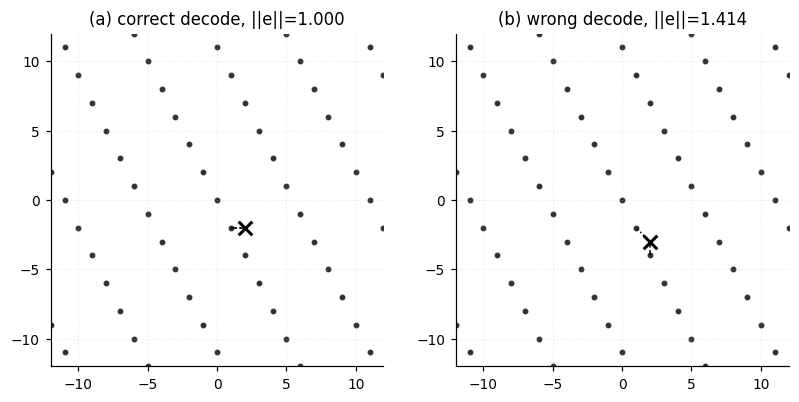

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))
for ax, (target, decoded, label, e_used) in zip(
    axes,
    [(target_a, decoded_a, "(a) correct decode", e_a),
     (target_b, decoded_b, "(b) wrong decode", e_b)],
):
    xs = [p[0] for p in pts_fig]
    ys = [p[1] for p in pts_fig]
    ax.scatter(xs, ys, s=8, color="0.2")
    ax.scatter(*target, marker="x", s=80, color="0.0", linewidths=2)
    ax.plot([target[0], decoded[0]], [target[1], decoded[1]], "k--", linewidth=1)
    ax.plot([target[0], noiseless[0]], [target[1], noiseless[1]], "k:", linewidth=1)
    ax.set_title(f"{label}, ||e||={np.linalg.norm(e_used):.3f}")
    ax.set_xlim(-12, 12)
    ax.set_ylim(-12, 12)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---

## What to take away

SIS and LWE are not new mathematics — they are Chapter 6's SVP and BDD,
asked about the specific $q$-ary lattices Chapter 5 built, for a randomly
drawn $A$ rather than a fixed one. That single change, from *one lattice*
to *a distribution over lattices*, is the entire content of "average-case"
in this chapter, and it is what a real key-generation algorithm actually
needs. Part B's reduction is a genuine piece of mathematics running on real
(if toy-scale) data, not a metaphor. Part C's honest limitation — Python
gives no real constant-time guarantee, so the lab can only show the
control-flow shape, not measure an actual side channel — is itself the
chapter's point: the vulnerability lives in *which operations run*, not in
how fast they run in any one language. Part D is the same warning
Chapter 6 gave about BDD's uniqueness threshold, made unavoidable: cross it,
and a mathematically correct decoder still returns the wrong answer.

In [12]:
# --------------------------------------------------------------------------
# CI smoke test. Runs on every commit; keeps this notebook honest against
# library updates. If this cell fails, the lab is broken -- please open an issue.
# --------------------------------------------------------------------------
def _selftest():
    beta_, sols_ = sis_bruteforce(np.array([[2, 1]]), 5)
    assert abs(beta_ - sqrt(5)) < 1e-9
    assert set(sols_) == {(2, 1), (-2, -1), (-1, 2), (1, -2)}

    q_, n_, bound_ = 13, 2, 1
    oracle_ = make_decision_oracle(n_, q_, bound_)
    random.seed(42)
    s_ = [random.randrange(q_) for _ in range(n_)]
    samples_ = gen_lwe_samples(s_, 8, q_, bound_, n_)
    recovered_ = recover_secret_via_oracle(oracle_, samples_, q_, n_)
    assert recovered_ == s_
    random.seed(0)

    draws_ = sample_cbd(2, size=500_000)
    assert abs(draws_.var() - 1.0) < 0.03

    q_f, a_f = 11, np.array([3, 5])
    pts_f = lwe_lattice_points(a_f, q_f)
    nz_f = [p for p in pts_f if p != (0, 0)]
    lam1_f = min(np.linalg.norm(p) for p in nz_f)
    assert abs(lam1_f - sqrt(5)) < 1e-9

    noiseless_f = center((4 * a_f) % q_f, q_f)
    assert tuple(noiseless_f) == (1, -2)

    d_a, _ = bdd_decode(center(noiseless_f + np.array([1, 0]), q_f), pts_f)
    assert d_a == (1, -2)
    d_b, _ = bdd_decode(center(noiseless_f + np.array([1, -1]), q_f), pts_f)
    assert d_b == (2, -4)

    return "all checks passed"

print(_selftest())

all checks passed
